In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

from google.colab import files

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [2]:
%matplotlib inline
#System Imports
import json
import glob
import os

#Library Imports
from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

In [3]:
#directory_name = "gdrive/MyDrive/Colab Notebooks/GESTALT/"
directory_name = "GESTALT-main/code/"

In [ ]:
import pandas as pd

#obj = pd.read_csv("../data/SV/output/ownershipAssignment/objects.csv")
#loc = pd.read_csv("../data/SV/output/ownershipAssignment/locations.csv")

obj = pd.read_csv("../data/DC/output/ownershipAssignment/objects.csv")
loc = pd.read_csv("../data/DC/output/ownershipAssignment/locations.csv")

print(obj.columns.tolist())
print(loc.columns.tolist())
print(obj.head())

['name', 'longitude', 'latitude', 'date', 'origin', 'source', 'object_prob', 'assignment_prob', 'ground_truth_location']
['name', 'longitude', 'latitude', 'date', 'origin', 'source', 'class_confidence', 'ground_truth_location']
             name   longitude   latitude               date origin  \
0        crossing  115.982075 -31.895145  19-10-23 14:40:12    osm   
1        crossing  115.976219 -31.898668  19-10-23 14:40:12    osm   
2  level_crossing  115.981850 -31.895455  19-10-23 14:40:12    osm   
3  level_crossing  115.988869 -31.892207  19-10-23 14:40:12    osm   
4  level_crossing  115.996081 -31.891174  19-10-23 14:40:12    osm   

                                        source  object_prob  assignment_prob  \
0  https://www.openstreetmap.org/node/32485733          0.7                1   
1  https://www.openstreetmap.org/node/32522370          0.7                1   
2  https://www.openstreetmap.org/node/32522378          0.7                1   
3  https://www.openstreetmap.or

         latitude  longitude
count   18.000000  18.000000
mean   116.018183 -31.814353
std      0.000146   0.000257
min    116.017805 -31.814622
25%    116.018185 -31.814510
50%    116.018220 -31.814397
75%    116.018261 -31.814301
max    116.018337 -31.813546
      latitude  longitude
275  116.01822 -31.814194


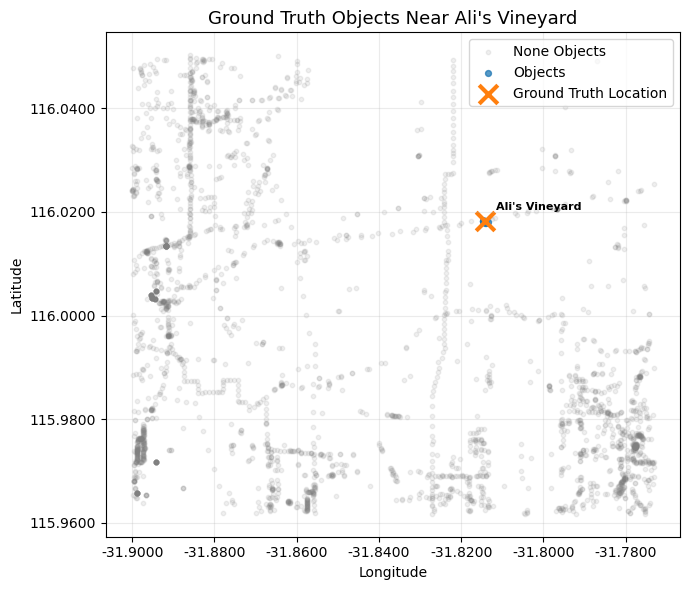

         latitude  longitude
count   18.000000  18.000000
mean   116.018183 -31.814353
std      0.000146   0.000257
min    116.017805 -31.814622
25%    116.018185 -31.814510
50%    116.018220 -31.814397
75%    116.018261 -31.814301
max    116.018337 -31.813546
      latitude  longitude
275  116.01822 -31.814194


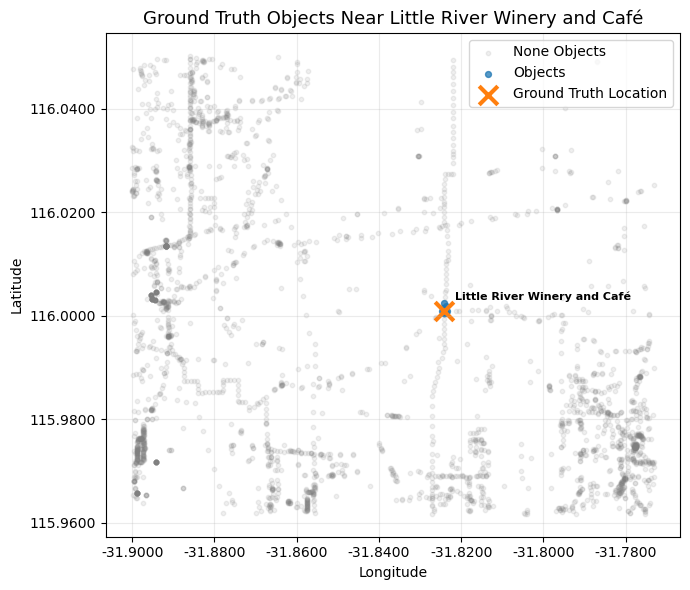

         latitude  longitude
count   18.000000  18.000000
mean   116.018183 -31.814353
std      0.000146   0.000257
min    116.017805 -31.814622
25%    116.018185 -31.814510
50%    116.018220 -31.814397
75%    116.018261 -31.814301
max    116.018337 -31.813546
      latitude  longitude
275  116.01822 -31.814194


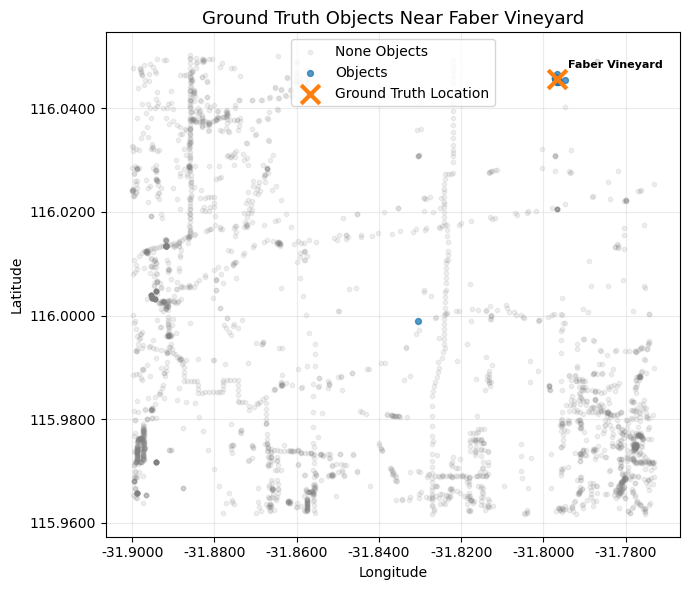

         latitude  longitude
count   18.000000  18.000000
mean   116.018183 -31.814353
std      0.000146   0.000257
min    116.017805 -31.814622
25%    116.018185 -31.814510
50%    116.018220 -31.814397
75%    116.018261 -31.814301
max    116.018337 -31.813546
      latitude  longitude
275  116.01822 -31.814194


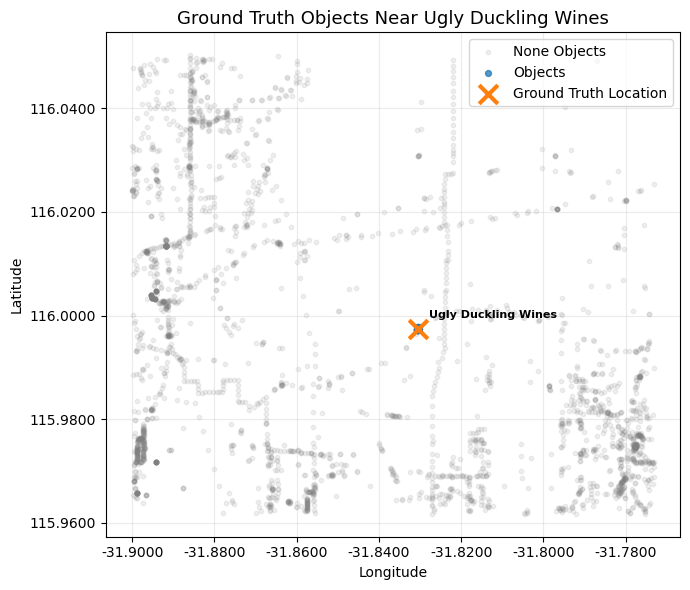

         latitude  longitude
count   18.000000  18.000000
mean   116.018183 -31.814353
std      0.000146   0.000257
min    116.017805 -31.814622
25%    116.018185 -31.814510
50%    116.018220 -31.814397
75%    116.018261 -31.814301
max    116.018337 -31.813546
      latitude  longitude
275  116.01822 -31.814194


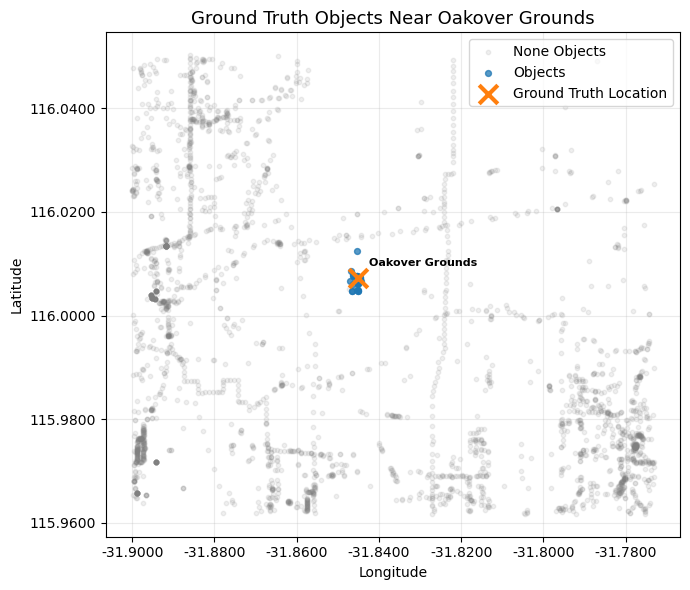

         latitude  longitude
count   18.000000  18.000000
mean   116.018183 -31.814353
std      0.000146   0.000257
min    116.017805 -31.814622
25%    116.018185 -31.814510
50%    116.018220 -31.814397
75%    116.018261 -31.814301
max    116.018337 -31.813546
      latitude  longitude
275  116.01822 -31.814194


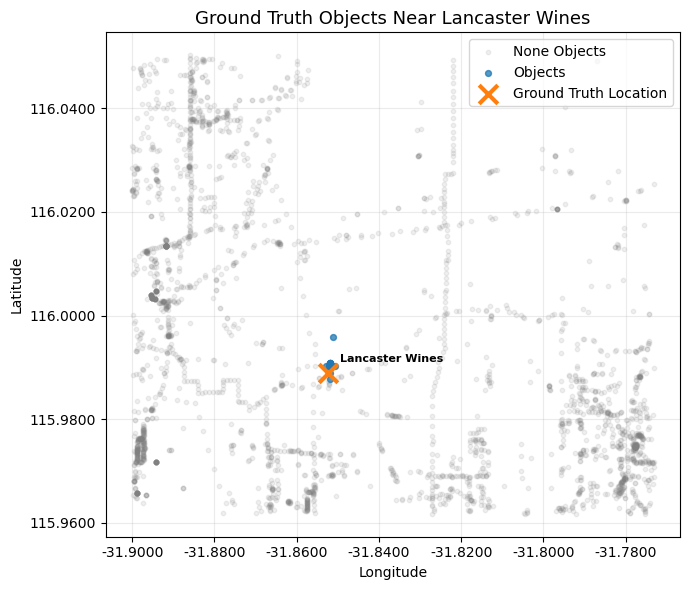

In [8]:
class ClusteringViz:
    def __init__(self, object_filename, location_filename):
        self.obj_df = pd.read_csv(object_filename)[
        ["ground_truth_location", "name", "latitude", "longitude"]
        ].copy()

        self.obj_df = self.obj_df.rename(columns={
        "ground_truth_location": "true_location",
        "name": "object"
        })
        temp = self.obj_df["longitude"].copy()
        self.obj_df["longitude"] = self.obj_df["latitude"]
        self.obj_df["latitude"] = temp
        self.location_df = pd.read_csv(location_filename)[['name','latitude','longitude']].copy()
        self.location_df = self.location_df.rename(columns={"name": "location"})
        temp = self.location_df['longitude'].copy()
        self.location_df['longitude'] = self.location_df['latitude']
        self.location_df['latitude'] = temp

        # -- just added --
        self.target_locations = [
            "Ali's Vineyard",
            "Little River Winery and Café",
            "Faber Vineyard",
            "Ugly Duckling Wines",
            "Oakover Grounds",
            "Lancaster Wines",
        ]

        self.color_dict = {
            "Ali's Vineyard": "blue",
            "Little River Winery and Café": "red",
            "Faber Vineyard": "green",
            "Ugly Duckling Wines": "purple",
            "Oakover Grounds": "orange",
            "Lancaster Wines": "cyan",
        }

        # Universal plotting prep
        self.xlim_dict = {"Ali's Vineyard":(116.01817, 116.01835), 
                          'Little River Winery and Café':(116.0005, 116.0012), 
                          'Ugly Duckling Wines':(115.9972, 115.9978), 
                          'Oakover Grounds':(116.0045, 116.009), 
                          'Faber Vineyard':(116.045, 116.0461), 
                          'Lancaster Wines':(115.987, 115.997), 
                          'ALL':(115.98, 116.05) }
        self.ylim_dict = {"Ali's Vineyard":(-31.8147, -31.8141), 
                          'Little River Winery and Café':(-31.8244, -31.82338), 
                          'Ugly Duckling Wines':(-31.8307, -31.8302), 
                          'Oakover Grounds':(-31.8472, -31.8441), 
                          'Faber Vineyard':(-31.7971, -31.7962), 
                          'Lancaster Wines':(-31.853, -31.8510), 
                          'ALL':(-31.86, -31.79)}

        ###self.color_dict = defaultdict(lambda : "gray")
        ###self.color_dict.update({"Ali's Vineyard":"blue", 'Little River Winery and Café':"red", 'Faber Vineyard':"green", 'Ugly Duckling Wines':"purple", 'Oakover Grounds':"orange", 'Lancaster Wines':"cyan"})

    def plot_object_location(self, loc_name, save=True):
        fig, ax = plt.subplots(figsize=(7, 6))

        none_objects = self.obj_df[self.obj_df["true_location"].isna()]

        ax.scatter(
        none_objects["longitude"],
        none_objects["latitude"],
        color="gray",
        alpha=0.12,
        s=10,
        label="None Objects"
        )

        obj_subset = self.obj_df[self.obj_df["true_location"] == loc_name]
        loc_subset = self.location_df[self.location_df["location"] == loc_name]

        ax.scatter(
            obj_subset["longitude"],
            obj_subset["latitude"],
            s=18,
            alpha=0.75,
            label="Objects"
        )

        ax.scatter(
            loc_subset["longitude"],
            loc_subset["latitude"],
            marker="x",
            s=180,
            linewidths=3,
            label="Ground Truth Location"
        )

        if len(loc_subset) > 0:
            x = loc_subset.iloc[0]["longitude"]
            y = loc_subset.iloc[0]["latitude"]
            ax.annotate(
                loc_name,
                (x, y),
                xytext=(8, 8),
                textcoords="offset points",
                fontsize=8,
                fontweight="bold"
            )
        print(viz.obj_df[viz.obj_df["true_location"] == "Ali's Vineyard"][["latitude", "longitude"]].describe())
        print(viz.location_df[viz.location_df["location"] == "Ali's Vineyard"][["latitude", "longitude"]])

        #ax.set_xlim(self.xlim_dict[loc_name])
        #ax.set_ylim(self.ylim_dict[loc_name])

        ax.ticklabel_format(useOffset=False)
        ax.xaxis.set_major_formatter(FormatStrFormatter("%.4f"))
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.4f"))

        ax.set_title(f"Ground Truth Objects Near {loc_name}", fontsize=13)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.legend(loc="best")
        ax.grid(True, alpha=0.25)

        plt.tight_layout()

        if save:
            safe_name = loc_name.lower().replace(" ", "_").replace("'", "").replace("&", "and")
            plt.savefig(f"../imgs/{safe_name}_ground_truth_objects.png", dpi=300)

        plt.show()

    def plot_all_locations(self):
        for loc in self.target_locations:
            self.plot_object_location(loc)



    '''    
    def plot_object_locations(self, loc_name, ax):
        # Plot labels
        ax.set_title('Ground Truth Tags for ' + loc_name, fontsize=9)

        # Control zoom of plot
        ax.set_xlim(self.xlim_dict[loc_name])
        ax.set_ylim(self.ylim_dict[loc_name])

        # Fix scientific notation on axes
        ax.ticklabel_format(useOffset=False)
        ax.set_xticklabels(ax.get_xticks(), rotation=-45)
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.4f'))
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.4f'))

        # Plot objects
        ax.scatter(y=self.obj_df['latitude'], x=self.obj_df['longitude'], label="Objects", linewidth=1, s=8)

        # Plot locations
        ax.scatter(y=self.location_df['latitude'], x=self.location_df['longitude'], marker='x', label='Locations', color=[self.color_dict[i] for i in self.location_df['location']], linewidth=2, s=[200 for i in self.location_df['location']])

        # Annotations
        for i, txt in enumerate(self.obj_df['object']):
            ax.annotate(txt, (self.obj_df['longitude'][i], self.obj_df['latitude'][i]), size=8, va='top', ha='center')

        for i, txt in enumerate(self.location_df['location']):
            if txt in ["Ali's Vineyard", 'Little River Winery and Café', 'Faber Vineyard', 'Ugly Duckling Wines', 'Oakover Grounds', 'Lancaster Wines']:
                ax.annotate(txt, (self.location_df['longitude'][i], self.location_df['latitude'][i]), size=12, ha='center', va='bottom')

    def plot_locations(self, loc_name, title):
        # Plot labels
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.title(title)

        # Control zoom of plot
        plt.xlim(self.xlim_dict[loc_name])
        plt.ylim(self.ylim_dict[loc_name])

        # Fix scientific notation on axes
        plt.ticklabel_format(useOffset=False)

        # Plot objects
        plt.scatter(y=self.obj_df['latitude'], x=self.obj_df['longitude'], label="Objects", color='black', linewidth=1, s=8)

        # Plot locations
        plt.scatter(y=self.location_df['latitude'], x=self.location_df['longitude'], marker='x', label='Locations', color=[self.color_dict[i] for i in self.location_df['location']], linewidth=2, s=[200 for i in self.location_df['location']])

        # Legend
        plt.legend(['Objects', 'Other Locations'], loc='lower right')

        # Annotations
        for i, txt in enumerate(self.location_df['location']):
            if txt in ["Ali's Vineyard", 'Little River Winery and Café', 'Faber Vineyard', 'Ugly Duckling Wines', 'Oakover Grounds', 'Lancaster Wines']:
                plt.annotate(txt, (self.location_df['longitude'][i], self.location_df['latitude'][i]), size=16, ha='center', va='bottom')
'''


if __name__ == "__main__":
    viz = ClusteringViz(
    "../data/SV/output/ownershipAssignment/objects.csv",
    "../data/SV/output/ownershipAssignment/locations.csv"
    )

    # Save six clean individual plots
    viz.plot_all_locations()

    # Optional: also save all-location overview
    #fig = viz.plot_locations("ALL", title="Ground Truth Swan Valley Winery Locations")
    #plt.savefig("../imgs/loc_labels_plot.png", dpi=300, bbox_inches="tight")
    #plt.show()

    '''fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(14,10))
    fig.tight_layout(pad=3.0)

    viz.plot_object_locations("Little River Winery and Café", ax1)#'Little River Winery and Café')#'Ugly Duckling Wines')#'Oakover Grounds')#'Lancaster Wines')#'Faber Vineyard')
    viz.plot_object_locations("Ali's Vineyard", ax2)
    viz.plot_object_locations("Faber Vineyard", ax3)
    viz.plot_object_locations("Lancaster Wines", ax4)
    viz.plot_object_locations("Ugly Duckling Wines", ax5)
    viz.plot_object_locations("Oakover Grounds", ax6)

    fig.suptitle('Ground Truth Labels for Swan Valley Wineries Dataset')
    fig.supxlabel('Longitude')
    fig.supylabel('Latitude')
    fig.legend(['Objects', 'Other Locations'], loc='upper right')
    fig.tight_layout()

    plt.savefig("loc_obj_labels_plot.png")
    files.download("loc_obj_labels_plot.png")

    plt.figure()
    fig = viz.plot_locations("ALL", title='Ground Truth Swan Valley Winery Locations')
    plt.savefig("loc_labels_plot.png")
    files.download("loc_labels_plot.png")
    '''